# Visionset AI Model Training
<img src="./logo/logo.png" width="1000"/>

In [3]:
import os
import sys
import numpy as np
import pandas as pd

from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms

In [4]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

!python --version

Platform: win32
Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
---
torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu
Python 3.13.5


In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


In [6]:
train_dir = os.path.join("data", "train", "undersampled_dataset")

print("Data directory:", train_dir)

Data directory: data\train\undersampled_dataset


In [7]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [8]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4201, 0.3118, 0.2111], std=[0.2819, 0.2403, 0.2240])
    ]
)

In [9]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)
dataset

Dataset ImageFolder
    Number of datapoints: 488
    Root location: data\train\undersampled_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.4201, 0.3118, 0.2111], std=[0.2819, 0.2403, 0.224])
           )

In [10]:
classes = dataset.classes
classes

['fire_images', 'non_fire_images']

In [11]:
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.12% of full data
Validation data is 19.88% of full data


In [12]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [13]:
train_count = class_counts(train_dataset)
train_count

  0%|          | 0/391 [00:00<?, ?it/s]

fire_images        189
non_fire_images    202
dtype: int64

<Axes: >

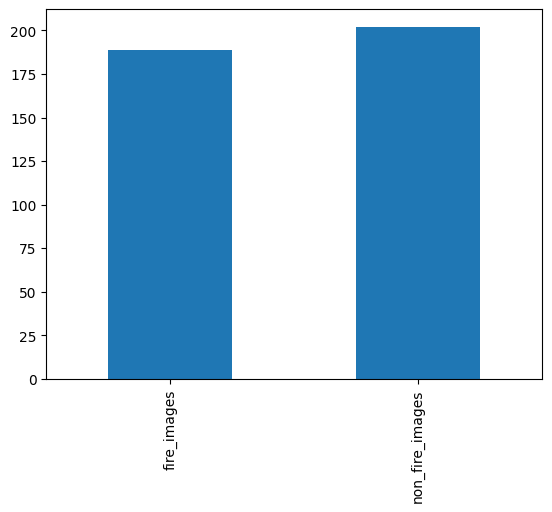

In [14]:
train_count.plot(kind="bar")

In [15]:
val_count = class_counts(val_dataset)
val_count

  0%|          | 0/97 [00:00<?, ?it/s]

fire_images        55
non_fire_images    42
dtype: int64

<Axes: >

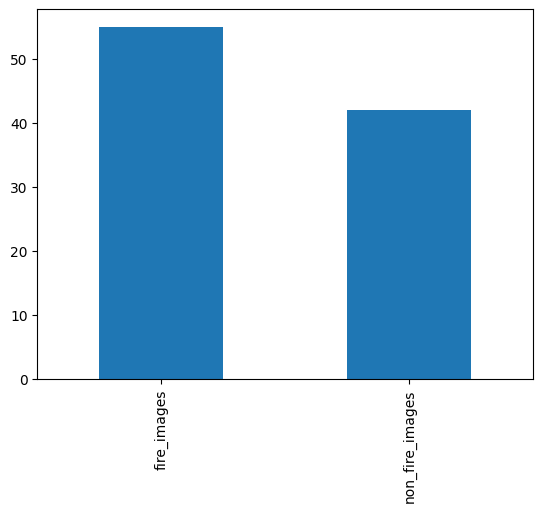

In [16]:
val_count.plot(kind="bar")

In [17]:
g = torch.Generator()
g.manual_seed(42)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

single_batch = next(iter(train_loader))[0]

print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])


In [18]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = torch.nn.Sequential()

conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding=1)
max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv1)
model.append(torch.nn.ReLU())
model.append(max_pool1)

conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1)
max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv2)
model.append(torch.nn.ReLU())
model.append(max_pool2)

conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
max_pool3 = torch.nn.MaxPool2d(2)
model.append(conv3)
model.append(torch.nn.ReLU())
model.append(max_pool3)

model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())

linear1 = torch.nn.Linear(in_features=50176, out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())

output_layer = torch.nn.Linear(500, 2)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=2, bias=True)
)

In [19]:
height, width = 224, 224
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 2]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

In [20]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.to(device)

print(loss_fn)
print("--------------------------------------------")
print(optimizer)

CrossEntropyLoss()
--------------------------------------------
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [21]:
from training import train, predict

In [22]:
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=30, device=device)

Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.84, Validation Loss: 0.34, Validation accuracy = 0.85


Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 29, Training Loss: 0.08, Validation Loss: 0.22, Validation accuracy = 0.93


Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 30, Training Loss: 0.12, Validation Loss: 0.21, Validation accuracy = 0.93


In [30]:
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=30, device=device)

Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.04, Validation Loss: 0.15, Validation accuracy = 0.93


Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 29, Training Loss: 0.00, Validation Loss: 0.48, Validation accuracy = 0.92


Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 30, Training Loss: 0.00, Validation Loss: 0.47, Validation accuracy = 0.92


In [ ]:
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=10, device=device)

Training:   0%|          | 0/13 [00:00<?, ?it/s]

Scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.00, Validation Loss: 0.47, Validation accuracy = 0.92


Training:   0%|          | 0/13 [00:00<?, ?it/s]

In [31]:
probabilities = predict(model, val_loader, device)
predictions = torch.argmax(probabilities, dim=1)

Predicting:   0%|          | 0/4 [00:00<?, ?it/s]

In [32]:
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

  0%|          | 0/4 [00:00<?, ?it/s]

In [33]:
classes

['fire_images', 'non_fire_images']

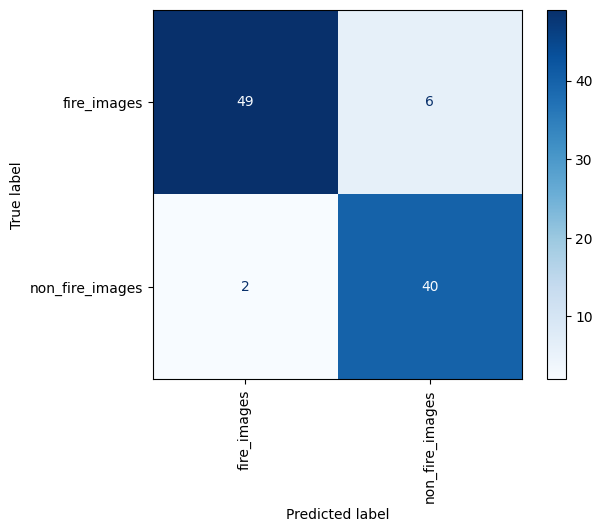

In [36]:
cm = confusion_matrix(targets, predictions.cpu())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show();

In [35]:
torch.save(model, "model/VSAI-FDS726.pth")

---
# This file &#169; 2026 by [Visionset AI](https://www.visionsetai.netify.app/).
<img src="./logo/title.png" width="1000"/>